# B-4064A — Anomalias OCSVM (multivariado) | Treino: Jan–Abr/2024

One-Class SVM com kernel RBF. Período de treino encurtado até Abr/2024 para excluir possível degradação precoce em Mai–Jul/2024.

In [6]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from clearml import Task

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.loading import load_equipment_data
from transpetro_modelos.data.preprocessing import run_preprocessing


In [7]:
# ==============================
# Configuracao
# ==============================
TASK_ID = 'ab8de7d457e64521b21d1369a3a20a30'  # OCSVM multivariado | treino Jan-Abr/2024 | moving_average
EQUIPMENT_ID = 'B-4064A-novos'
USE_FULL_SCORES = True

# Eventos
EVENT_DATE_F1 = '2024-08-30 07:58'
EVENT_LABEL_F1 = 'Inicio restricao (30/Ago/2024)'
EVENT_DATE_F2 = '2025-04-07'
EVENT_LABEL_F2 = 'Inicio restricao (07/Abr/2025)'

# Janelas solicitadas
EVENT_TS_F1 = pd.Timestamp(EVENT_DATE_F1)
EVENT_TS_F2 = pd.Timestamp(EVENT_DATE_F2)

WINDOW_F1_ZOOM_START = EVENT_TS_F1 - pd.Timedelta(days=10)
WINDOW_F1_ZOOM_END = EVENT_TS_F1
WINDOW_2025_START = '2025-01-01'
WINDOW_2025_END = '2025-12-31'
WINDOW_F2_ZOOM_START = EVENT_TS_F2 - pd.Timedelta(days=10)
WINDOW_F2_ZOOM_END = EVENT_TS_F2

# Modo automatico de sensibilidade
AUTO_USE_CALIBRATED_SENSITIVITY = True
SENSITIVITY_PRESET = 'conservative'  # 'conservative' | 'balanced' | 'sensitive' | 'custom'
CALIB_START = '2025-05-01'
CALIB_END = '2025-12-31'
CALIB_PERCENTILES = [95, 97, 98, 99, 99.5, 99.7, 99.9]
CALIB_PERSISTENCE_GRID = [(1, 1), (2, 3), (3, 5), (4, 6)]
TARGET_ALERTS_PER_DAY = 2.0

# Visualizacao
PLOT_MODE = 'separated'  # 'separated' | 'consolidated'
ANOMALY_HIGHLIGHT_STYLE = 'lollipop'  # 'lollipop' | 'big_points'
SAVE_PLOTS = False

OUTPUT_DPI = 180
FIGSIZE_WIDTH = 12
PANEL_HEIGHT = 2.5

In [8]:
def _normalize_scores_df(scores):
    if not isinstance(scores, pd.DataFrame):
        raise TypeError(f'artifact de scores deve ser DataFrame, veio: {type(scores)}')

    required_cols = {'reconstruction_error', 'is_anomaly'}
    missing = required_cols - set(scores.columns)
    if missing:
        raise ValueError(f'colunas faltando em scores: {missing}')

    s = scores.copy()
    s.index = pd.to_datetime(s.index)
    s = s.sort_index()
    s['is_anomaly'] = s['is_anomaly'].astype(bool)
    return s[['reconstruction_error', 'is_anomaly']]


def load_task_outputs(task_id: str, use_full_scores: bool = True):
    task = Task.get_task(task_id=task_id)

    if 'results' not in task.artifacts:
        raise KeyError('artifact results nao encontrado na task')
    results = task.artifacts['results'].get()
    if 'threshold' not in results:
        raise KeyError('campo threshold nao encontrado em results')
    threshold = float(results['threshold'])

    score_artifact_name = None
    if use_full_scores and 'full_scores' in task.artifacts:
        score_artifact_name = 'full_scores'
    elif 'test_scores' in task.artifacts:
        score_artifact_name = 'test_scores'
    elif 'full_scores' in task.artifacts:
        score_artifact_name = 'full_scores'
    else:
        raise KeyError('nenhum artifact de score disponivel (full_scores/test_scores)')

    scores = _normalize_scores_df(task.artifacts[score_artifact_name].get())
    return task, results, threshold, scores, score_artifact_name


def load_plot_base(equipment_id: str):
    config = EQUIPMENT_CONFIGS[equipment_id]
    df_raw = load_equipment_data(equipment_id, from_clearml=False)

    # Pre-split para alinhar timestamps da serie de sensores ao score
    pre_steps = config.pre_split_steps
    if pre_steps:
        df_base, _, _ = run_preprocessing(df_raw, pre_steps, fitted_scaler=None)
    else:
        df_base = df_raw

    df_base = df_base.sort_index()
    df_base.index = pd.to_datetime(df_base.index)
    return df_base, config


def slice_window(df_base, scores, window_start, window_end):
    start_ts = pd.Timestamp(window_start)
    end_ts = pd.Timestamp(window_end)

    dfw = df_base.loc[start_ts:end_ts].copy()
    sw = scores.loc[start_ts:end_ts].copy()

    common_idx = dfw.index.intersection(sw.index)
    if len(common_idx) == 0:
        raise ValueError(f'nao ha intersecao de timestamps na janela {window_start}..{window_end}')

    return dfw.loc[common_idx], sw.loc[common_idx]


def print_preprocessing_confirmation(config):
    print('Preprocessamento aplicado para score/predict:')
    print('  1) Pre-split (base bruta):')
    for step in config.pre_split_steps:
        print(f'     - {step}')

    print('  2) Pos-split/predict (modelo): clip + normalize(robust),')
    print('     usando clip_bounds e scaler ajustados no treino (conforme train_equipment.py).')


def persistence_filter(flags: pd.Series, k: int, n: int) -> pd.Series:
    if k == 1 and n == 1:
        return flags.astype(bool)
    roll = flags.astype(int).rolling(window=n, min_periods=n).sum()
    return (roll >= k).fillna(False).astype(bool)


def recommend_sensitivity(scores: pd.DataFrame, calib_start: str, calib_end: str):
    calib = scores.loc[pd.Timestamp(calib_start):pd.Timestamp(calib_end)].copy()
    if calib.empty:
        raise ValueError(f'janela de calibracao vazia: {calib_start}..{calib_end}')

    rows = []
    for p in CALIB_PERCENTILES:
        thr = float(np.percentile(calib['reconstruction_error'].values, p))
        for (k, n) in CALIB_PERSISTENCE_GRID:
            flags = persistence_filter(scores['reconstruction_error'] > thr, k=k, n=n)
            n_days = max((scores.index.max().normalize() - scores.index.min().normalize()).days + 1, 1)
            alerts_per_day = float(flags.sum()) / float(n_days)
            rows.append({
                'percentile': float(p),
                'threshold': float(thr),
                'k': int(k),
                'n': int(n),
                'alerts_per_day': alerts_per_day,
                'distance_to_target': abs(alerts_per_day - TARGET_ALERTS_PER_DAY),
            })

    calib_df = pd.DataFrame(rows).sort_values(['distance_to_target', 'alerts_per_day']).reset_index(drop=True)
    best = calib_df.iloc[0]
    return {
        'threshold': float(best['threshold']),
        'k': int(best['k']),
        'n': int(best['n']),
        'percentile': float(best['percentile']),
        'alerts_per_day': float(best['alerts_per_day']),
        'table': calib_df,
    }


In [9]:
def plot_anomaly_panels(
    df_window: pd.DataFrame,
    scores_window: pd.DataFrame,
    threshold_flags: pd.Series,
    anomaly_flags: pd.Series,
    threshold: float,
    threshold_label: str,
    n_anomalies: int,
    event_date: pd.Timestamp,
    event_label: str,
    title: str,
    output_path: Path | None = None,
    dpi: int = 180,
    plot_mode: str = 'separated',
    save_plots: bool = False,
    anomaly_highlight_style: str = 'lollipop',
):
    plt.style.use('seaborn-v0_8-whitegrid')

    mode = str(plot_mode).strip().lower()
    if mode not in {'separated', 'consolidated'}:
        raise ValueError("plot_mode invalido. Use: 'separated' ou 'consolidated'")

    highlight_style = str(anomaly_highlight_style).strip().lower()
    if highlight_style not in {'lollipop', 'big_points'}:
        raise ValueError("anomaly_highlight_style invalido. Use: 'lollipop' ou 'big_points'")

    saved_paths = []
    sensors = list(df_window.columns)
    anomaly_idx = scores_window.index[anomaly_flags]

    def maybe_save(fig, suffix: str | None = None):
        if not save_plots:
            return None
        if output_path is None:
            raise ValueError('output_path eh obrigatorio quando save_plots=True')
        output_path.parent.mkdir(parents=True, exist_ok=True)
        if suffix:
            target = output_path.with_name(f"{output_path.stem}_{suffix}{output_path.suffix}")
        else:
            target = output_path
        fig.savefig(target, dpi=dpi, bbox_inches='tight')
        saved_paths.append(target)
        return target

    if mode == 'separated':
        for col in sensors:
            fig, ax = plt.subplots(1, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * 1.4), sharex=True)
            ax.plot(
                df_window.index,
                df_window[col],
                color='steelblue',
                linewidth=1.0,
                alpha=0.85,
                label=f'Serie Temporal: {col}',
            )

            anom_vals = df_window[col].reindex(anomaly_idx).dropna()
            if not anom_vals.empty:
                ax.scatter(
                    anom_vals.index,
                    anom_vals.values,
                    s=28,
                    color='red',
                    edgecolor='none',
                    zorder=4,
                    label='Anomalia',
                )

            ax.axvline(
                event_date,
                color='orange',
                linestyle='--',
                linewidth=1.4,
                label=event_label,
            )
            ax.set_ylabel(col, fontsize=9)
            ax.set_xlabel('Tempo (Data/Hora)', fontsize=10)
            ax.tick_params(axis='both', labelsize=8)
            ax.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)

            fig.suptitle(f'{title} | {col}', fontsize=14, fontweight='bold', y=0.995)
            fig.tight_layout(rect=[0, 0, 1, 0.96])
            sensor_slug = ''.join(ch if ch.isalnum() else '_' for ch in str(col)).strip('_').lower()
            maybe_save(fig, suffix=f'sensor_{sensor_slug}' if sensor_slug else 'sensor')
            plt.show()

        fig_s, ax_s = plt.subplots(1, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * 1.6), sharex=True)
        x = scores_window.index
        y = scores_window['reconstruction_error']
        ax_s.plot(x, y, color='purple', linewidth=0.9, alpha=0.55, label='Score de Anomalia (MSE)')
        ax_s.axhline(
            threshold,
            color='red',
            linestyle='--',
            linewidth=1.3,
            label=threshold_label,
        )
        ax_s.fill_between(x, threshold, y, where=(y > threshold), color='red', alpha=0.10)
        idx_thr = scores_window.index[threshold_flags]
        if len(idx_thr) > 0:
            ax_s.scatter(
                idx_thr,
                scores_window.loc[idx_thr, 'reconstruction_error'],
                s=8,
                color='orange',
                alpha=0.20,
                label='Cruzamento bruto (score > threshold)',
                zorder=2,
            )
        idx_pers = scores_window.index[anomaly_flags]
        if len(idx_pers) > 0:
            y_pers = scores_window.loc[idx_pers, 'reconstruction_error']
            if highlight_style == 'lollipop':
                baseline = float(np.nanmin(y)) if len(y) else 0.0
                ax_s.vlines(
                    idx_pers,
                    ymin=baseline,
                    ymax=y_pers.values,
                    color='red',
                    alpha=0.45,
                    linewidth=1.2,
                    zorder=4,
                    label='Persistencia (lollipop)',
                )
                ax_s.scatter(
                    idx_pers,
                    y_pers,
                    s=44,
                    facecolor='red',
                    edgecolor='white',
                    linewidth=0.9,
                    alpha=0.95,
                    label='Alerta com persistencia',
                    zorder=5,
                )
            else:
                ax_s.scatter(
                    idx_pers,
                    y_pers,
                    s=58,
                    facecolor='red',
                    edgecolor='white',
                    linewidth=1.0,
                    alpha=0.95,
                    label='Alerta com persistencia (pontos)',
                    zorder=5,
                )
        ax_s.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
        ax_s.text(
            0.99,
            0.97,
            f'Anomalias (persistencia): {int(n_anomalies)}',
            transform=ax_s.transAxes,
            ha='right',
            va='top',
            fontsize=8,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.7, edgecolor='gray'),
        )
        ax_s.set_ylabel('Score de Anomalia', fontsize=9)
        ax_s.set_xlabel('Tempo (Data/Hora)', fontsize=10)
        ax_s.tick_params(axis='both', labelsize=8)
        ax_s.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)

        fig_s.suptitle(f'{title} | Score de Anomalia', fontsize=14, fontweight='bold', y=0.995)
        fig_s.tight_layout(rect=[0, 0, 1, 0.96])
        maybe_save(fig_s, suffix='score')
        plt.show()
        return saved_paths

    n_rows = len(sensors) + 1
    fig, axes = plt.subplots(
        n_rows,
        1,
        figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * n_rows),
        sharex=True,
        gridspec_kw={'height_ratios': [1] * len(sensors) + [0.95]},
    )

    for i, col in enumerate(sensors):
        ax = axes[i]
        ax.plot(
            df_window.index,
            df_window[col],
            color='steelblue',
            linewidth=1.0,
            alpha=0.85,
            label=f'Serie Temporal: {col}',
        )

        anom_vals = df_window[col].reindex(anomaly_idx).dropna()
        if not anom_vals.empty:
            ax.scatter(
                anom_vals.index,
                anom_vals.values,
                s=28,
                color='red',
                edgecolor='none',
                zorder=4,
                label='Anomalia',
            )

        ax.axvline(
            event_date,
            color='orange',
            linestyle='--',
            linewidth=1.4,
            label=event_label,
        )
        ax.set_ylabel(col, fontsize=9)
        ax.tick_params(axis='both', labelsize=8)
        ax.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)

    ax_s = axes[-1]
    x = scores_window.index
    y = scores_window['reconstruction_error']
    ax_s.plot(x, y, color='purple', linewidth=0.9, alpha=0.55, label='Score de Anomalia (MSE)')
    ax_s.axhline(
        threshold,
        color='red',
        linestyle='--',
        linewidth=1.3,
        label=threshold_label,
    )
    ax_s.fill_between(x, threshold, y, where=(y > threshold), color='red', alpha=0.10)
    idx_thr = scores_window.index[threshold_flags]
    if len(idx_thr) > 0:
        ax_s.scatter(
            idx_thr,
            scores_window.loc[idx_thr, 'reconstruction_error'],
            s=8,
            color='orange',
            alpha=0.20,
            label='Cruzamento bruto (score > threshold)',
            zorder=2,
        )
    idx_pers = scores_window.index[anomaly_flags]
    if len(idx_pers) > 0:
        y_pers = scores_window.loc[idx_pers, 'reconstruction_error']
        if highlight_style == 'lollipop':
            baseline = float(np.nanmin(y)) if len(y) else 0.0
            ax_s.vlines(
                idx_pers,
                ymin=baseline,
                ymax=y_pers.values,
                color='red',
                alpha=0.45,
                linewidth=1.2,
                zorder=4,
                label='Persistencia (lollipop)',
            )
            ax_s.scatter(
                idx_pers,
                y_pers,
                s=44,
                facecolor='red',
                edgecolor='white',
                linewidth=0.9,
                alpha=0.95,
                label='Alerta com persistencia',
                zorder=5,
            )
        else:
            ax_s.scatter(
                idx_pers,
                y_pers,
                s=58,
                facecolor='red',
                edgecolor='white',
                linewidth=1.0,
                alpha=0.95,
                label='Alerta com persistencia (pontos)',
                zorder=5,
            )
    ax_s.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
    ax_s.text(
        0.99,
        0.97,
        f'Anomalias (persistencia): {int(n_anomalies)}',
        transform=ax_s.transAxes,
        ha='right',
        va='top',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.7, edgecolor='gray'),
    )
    ax_s.set_ylabel('Score de Anomalia', fontsize=9)
    ax_s.set_xlabel('Tempo (Data/Hora)', fontsize=10)
    ax_s.tick_params(axis='both', labelsize=8)
    ax_s.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)

    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.99])
    maybe_save(fig)
    plt.show()
    return saved_paths


Preprocessamento aplicado para score/predict:
  1) Pre-split (base bruta):
     - {'step': 'remove_sensor_errors', 'error_values': [-25.0]}
     - {'step': 'resample', 'freq': '1h'}
     - {'step': 'ffill', 'limit': 6}
     - {'step': 'filter_running', 'column': 'Corrente', 'threshold': 5.0}
     - {'step': 'filter_running', 'column': 'Pressão Descarga', 'threshold': 0.0}
  2) Pos-split/predict (modelo): clip + normalize(robust),
     usando clip_bounds e scaler ajustados no treino (conforme train_equipment.py).

Task: ab8de7d457e64521b21d1369a3a20a30
Artifact de score usado: full_scores
Threshold (results): 0.000025

Preset de sensibilidade: conservative
  Percentis: [99, 99.5, 99.7, 99.9]
  Grid persistencia: [(3, 5), (4, 6), (5, 8)]
  Meta alerts/day: 0.5
  Plot mode: separated
  Anomaly highlight style: lollipop
  Save plots: False

Sensibilidade automatica ativa:
  Janela calibracao: 2025-05-01 .. 2025-12-31
  Recomendado -> threshold=6.769685, percentile=99.0, k=3, n=5
  Alerts/d

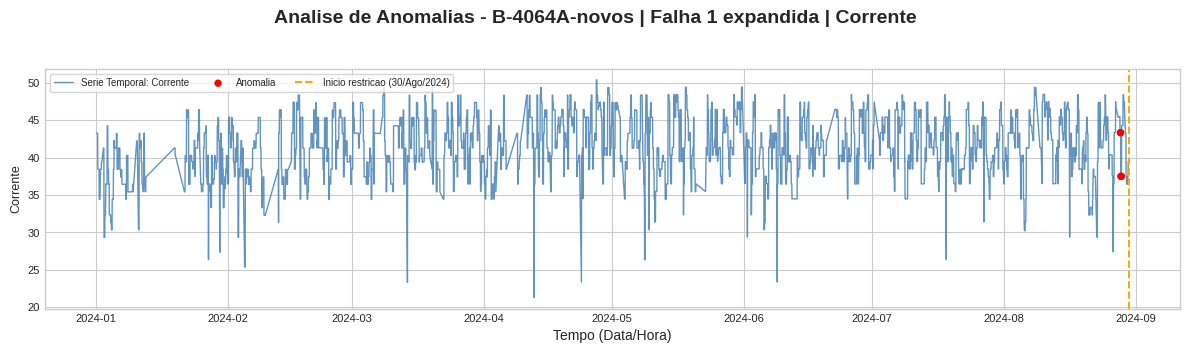

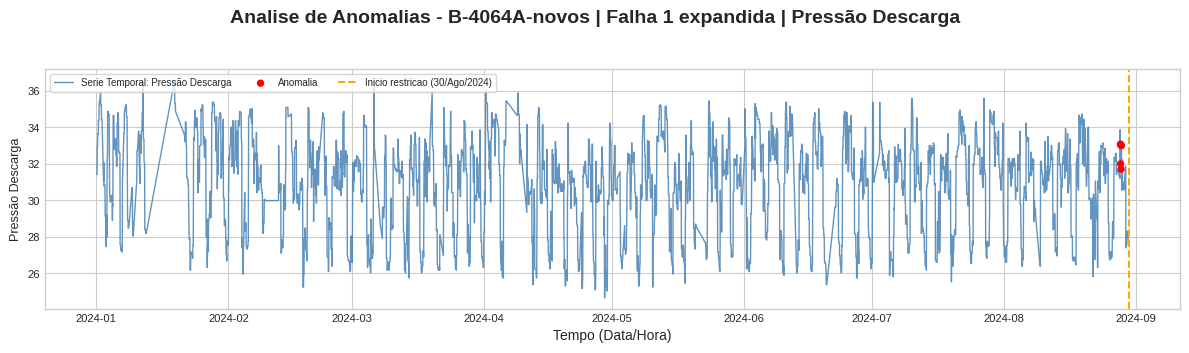

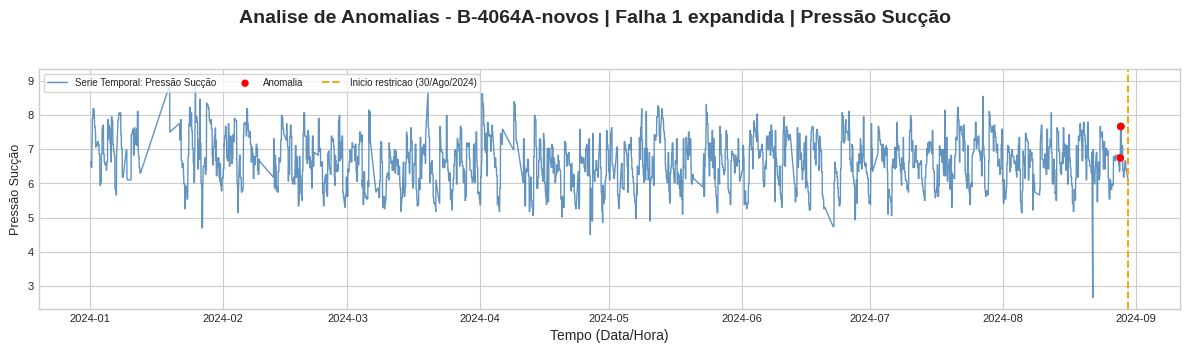

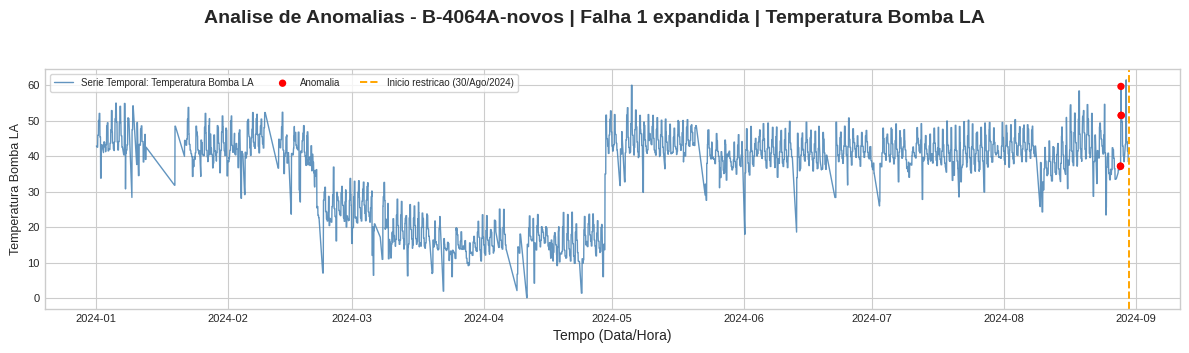

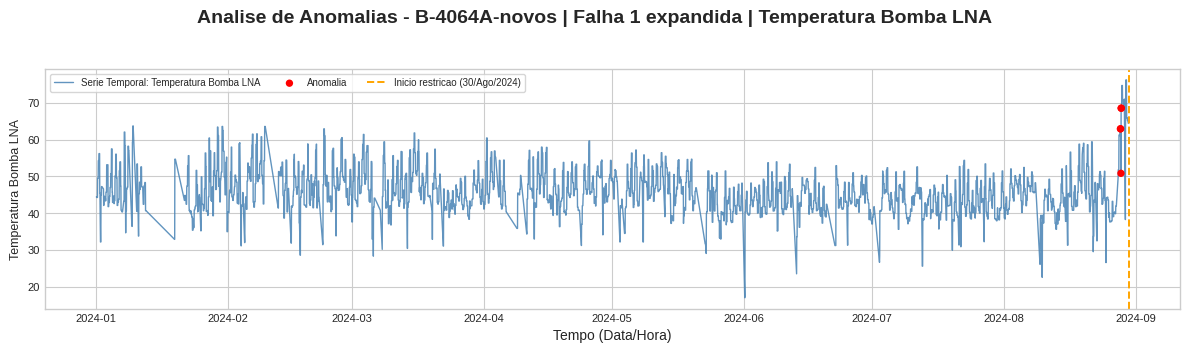

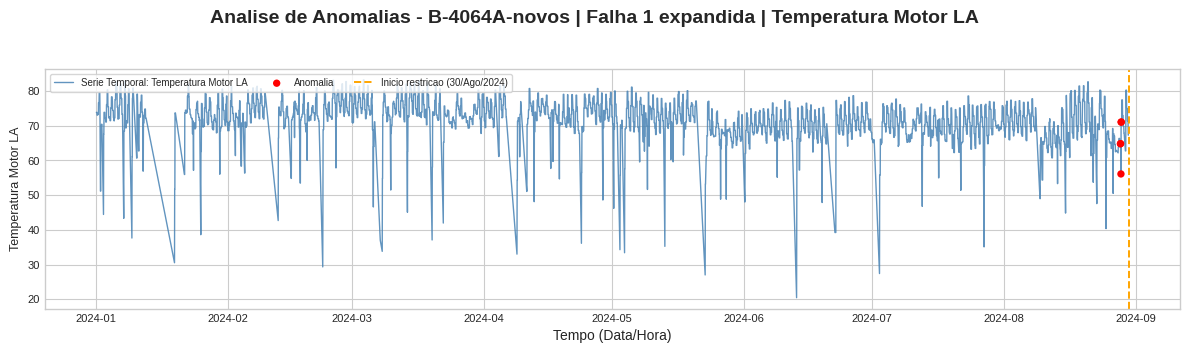

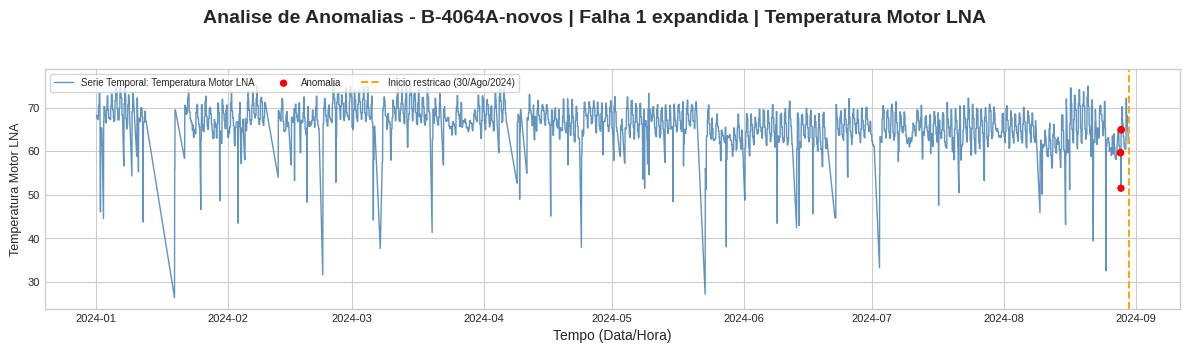

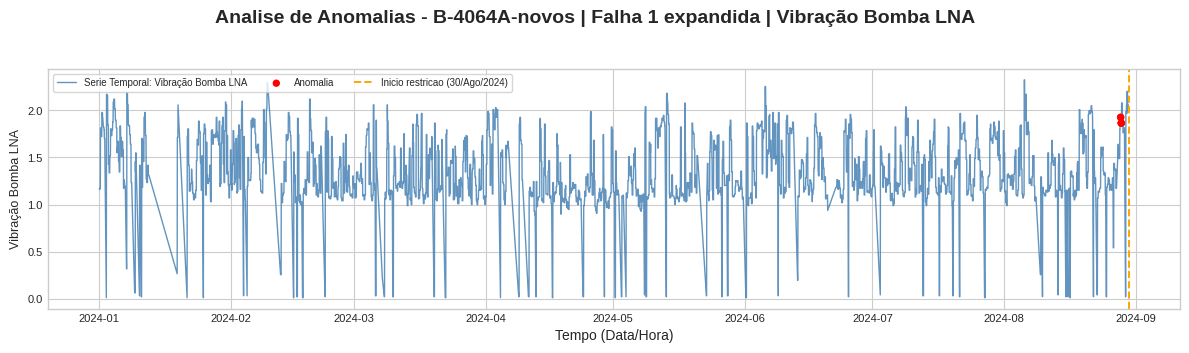

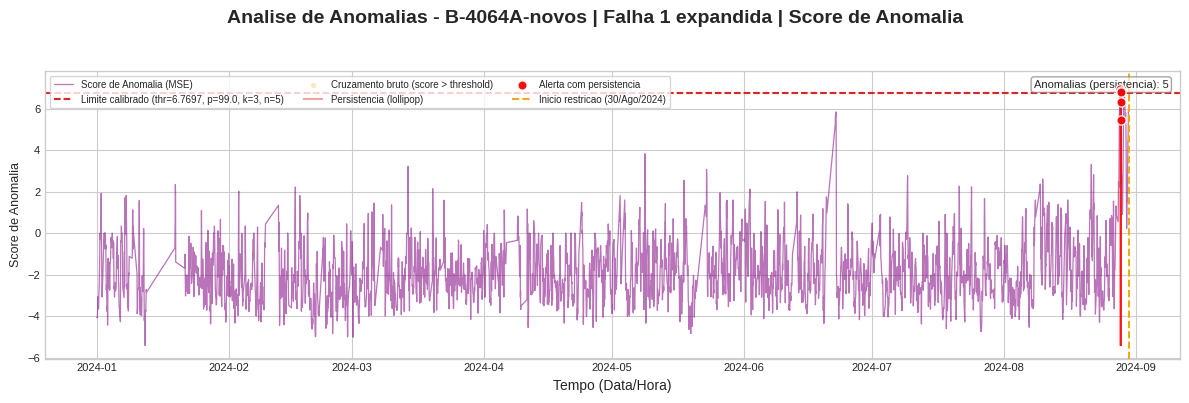

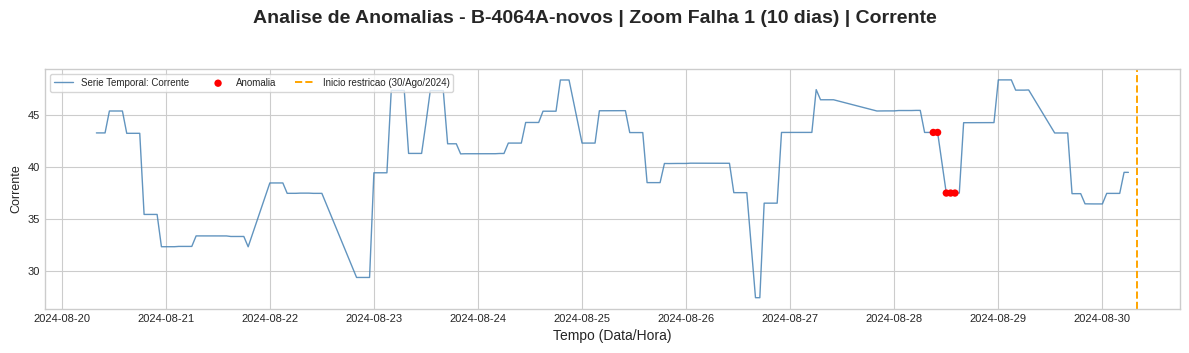

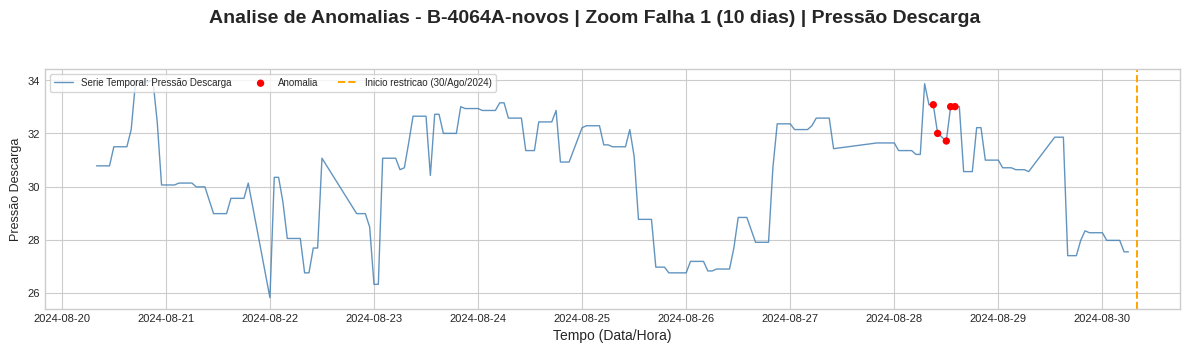

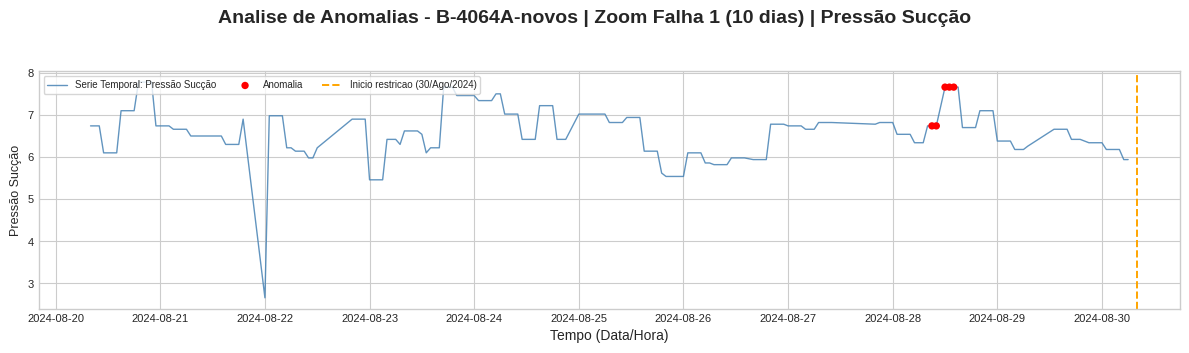

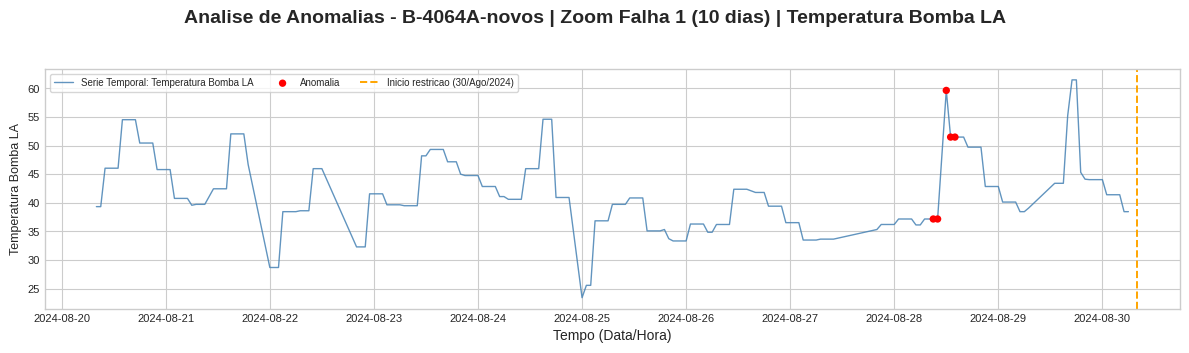

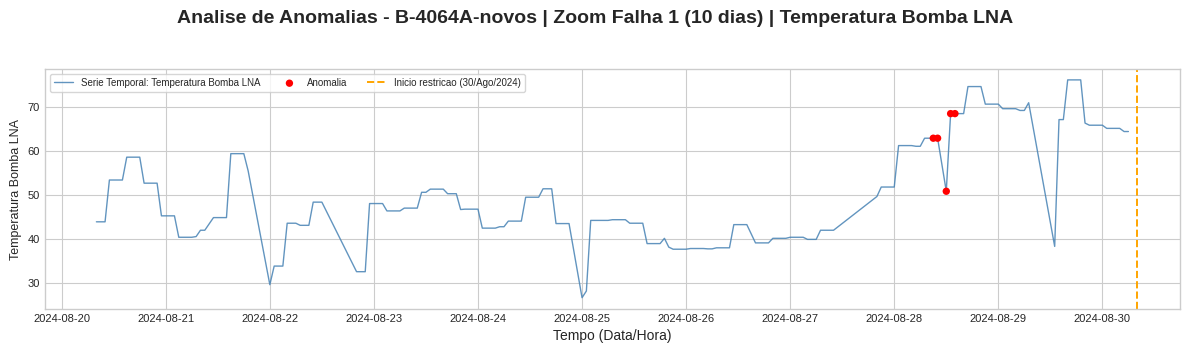

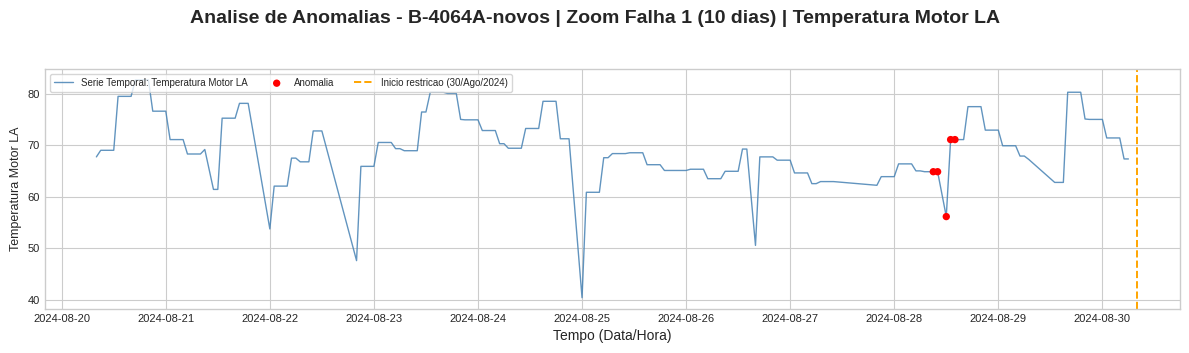

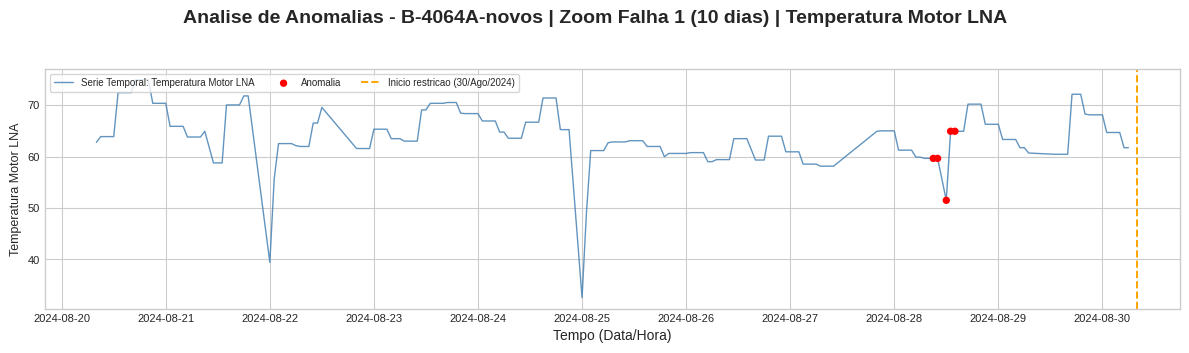

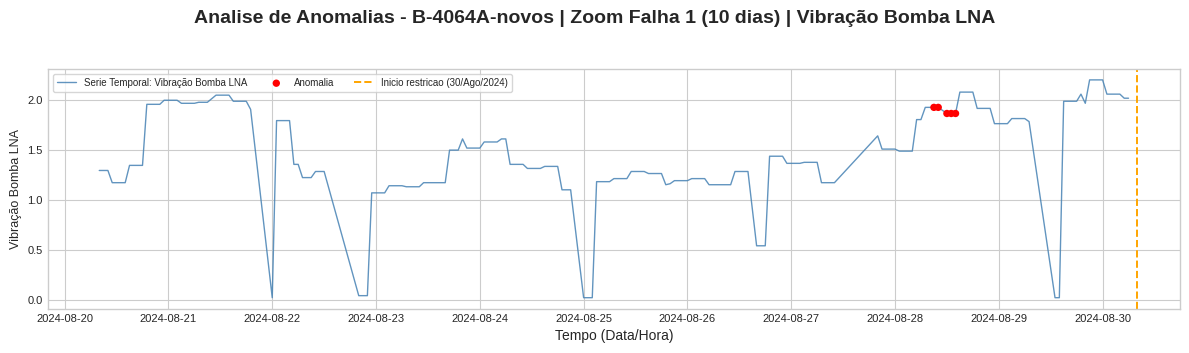

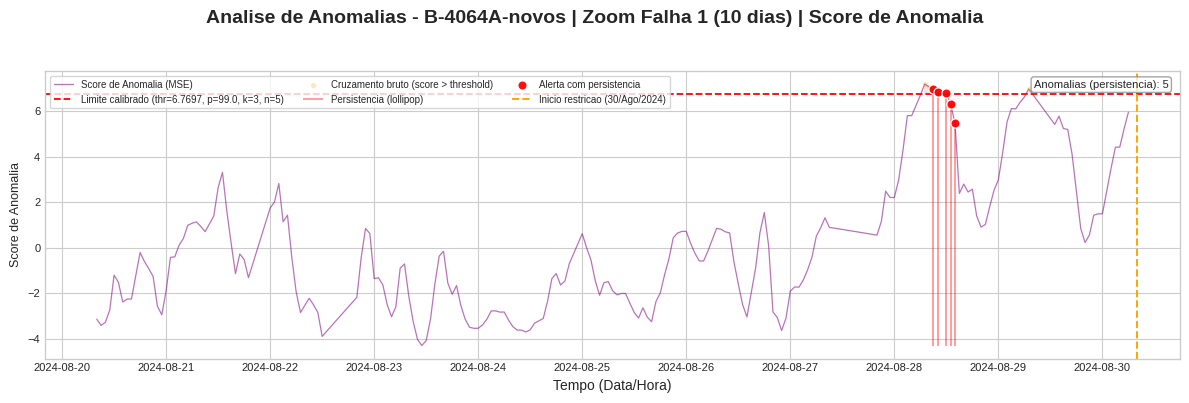

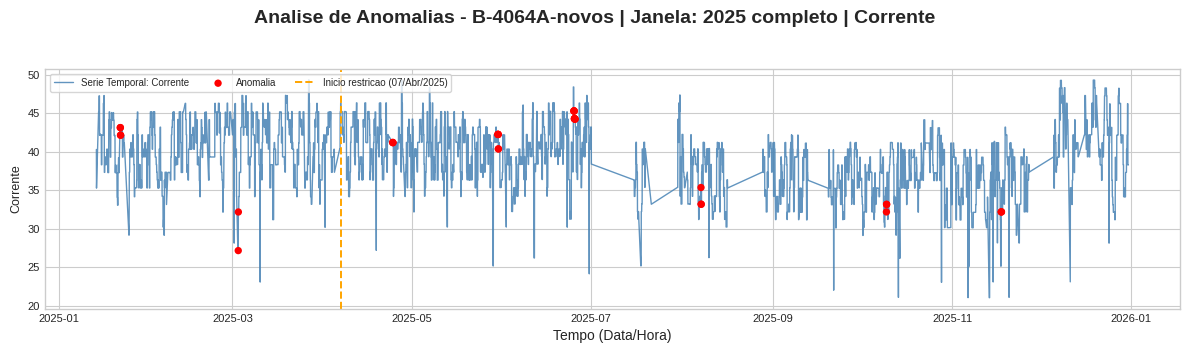

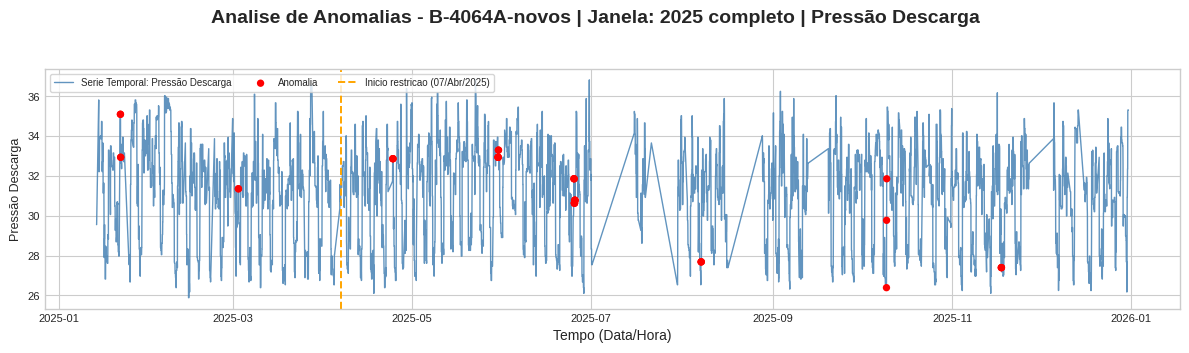

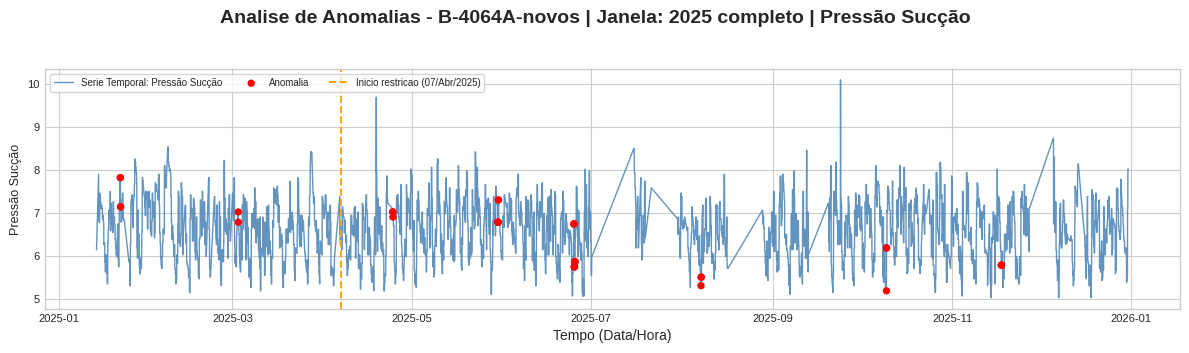

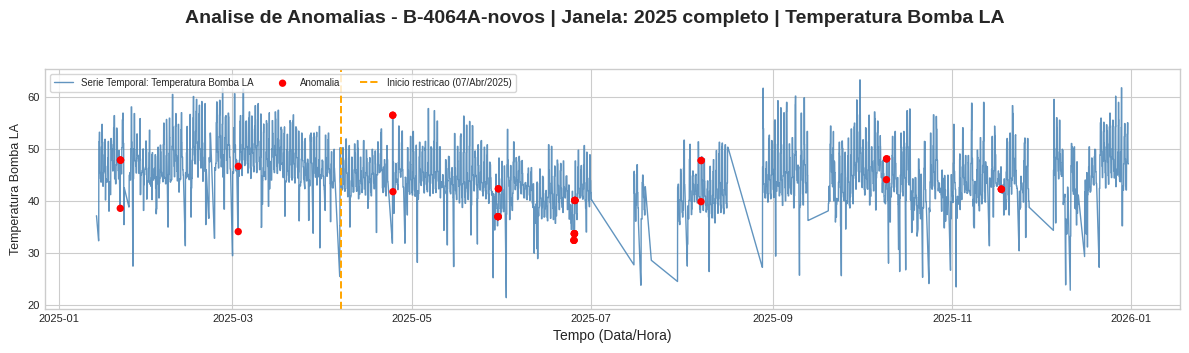

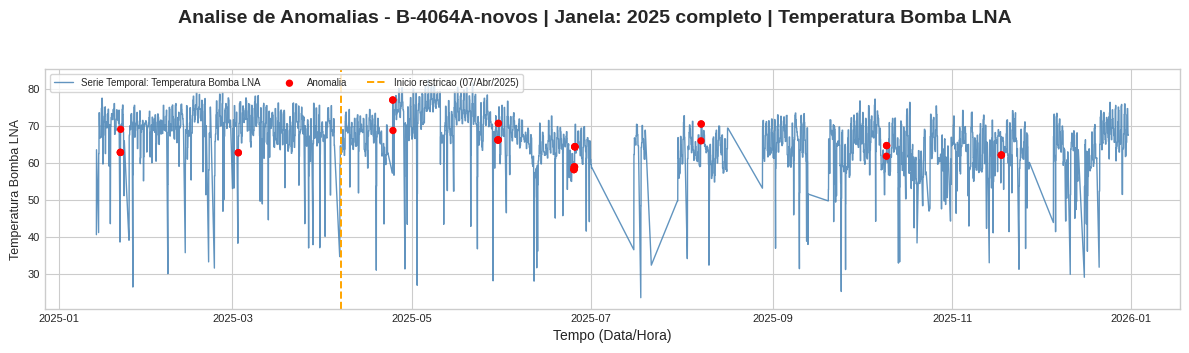

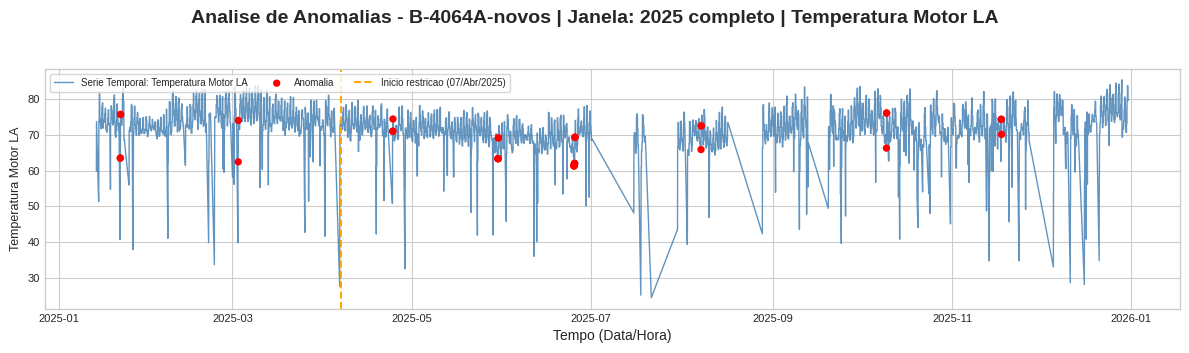

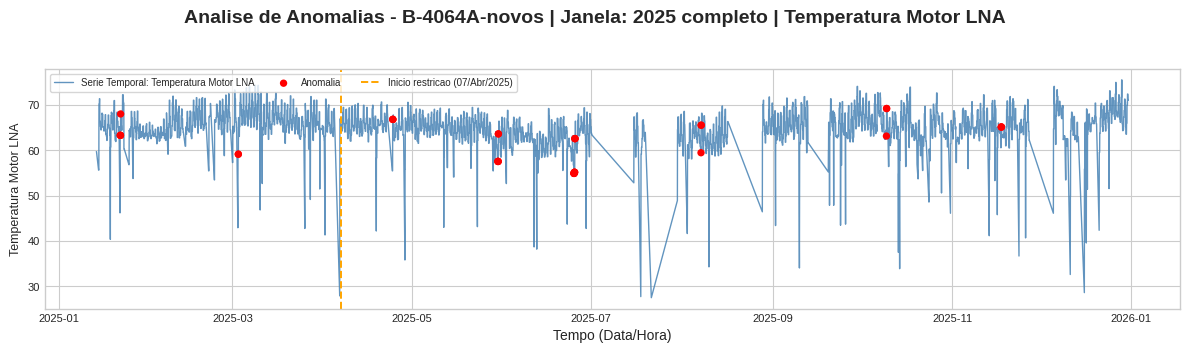

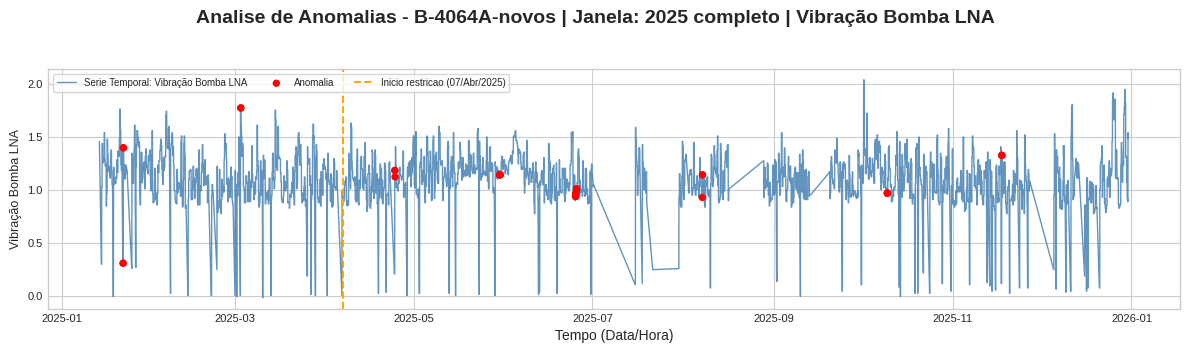

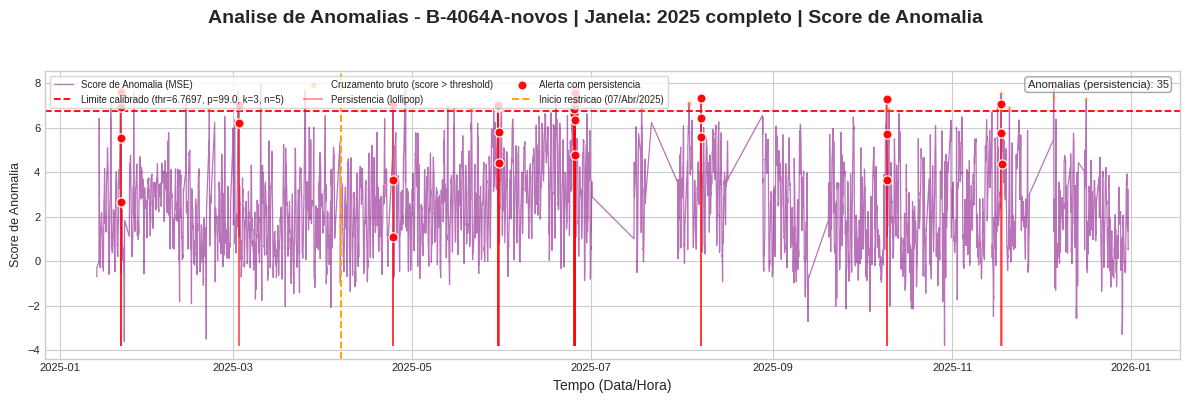

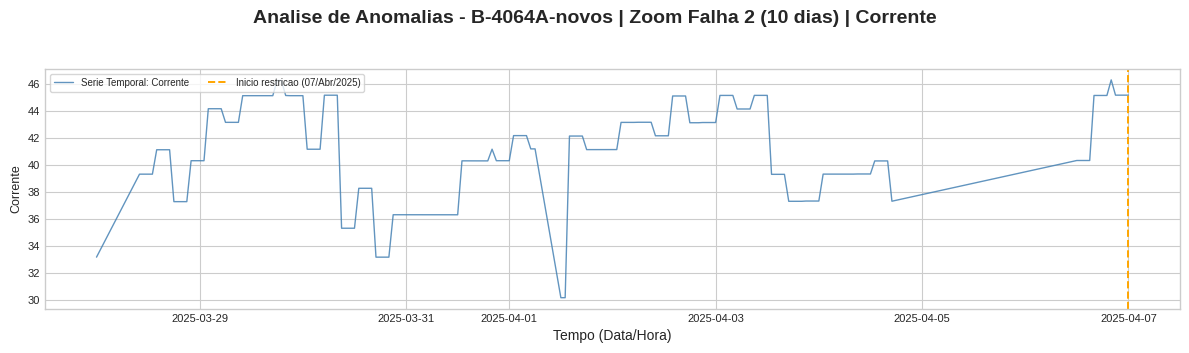

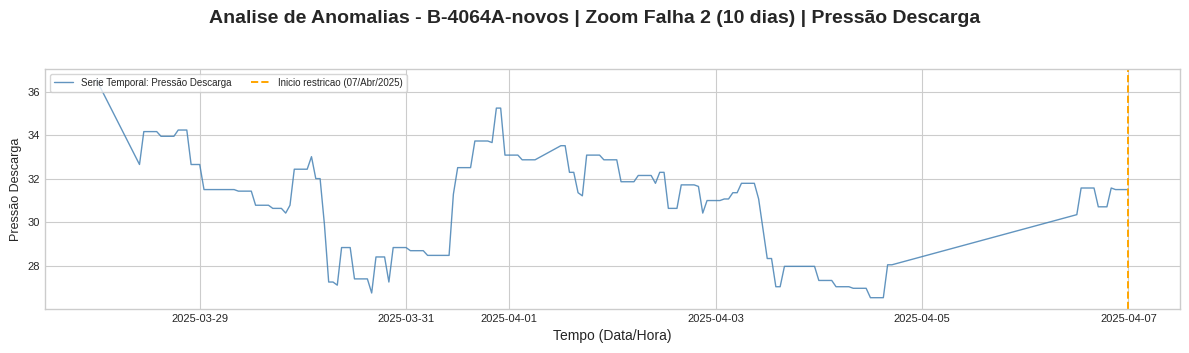

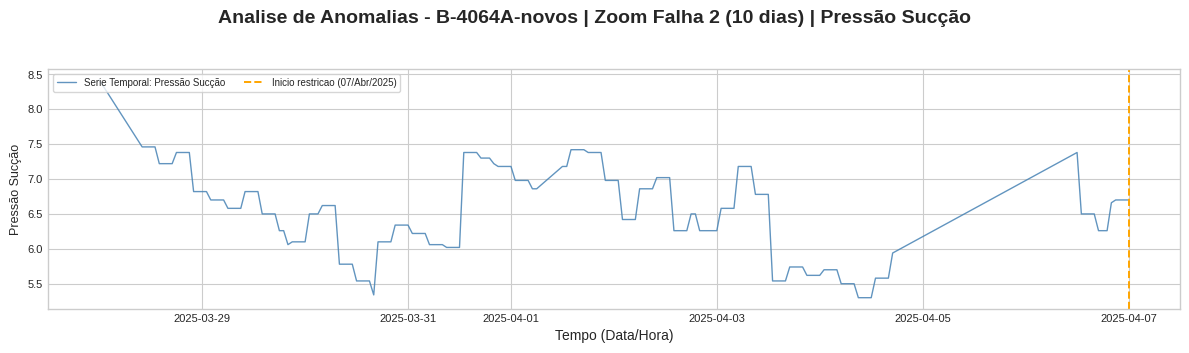

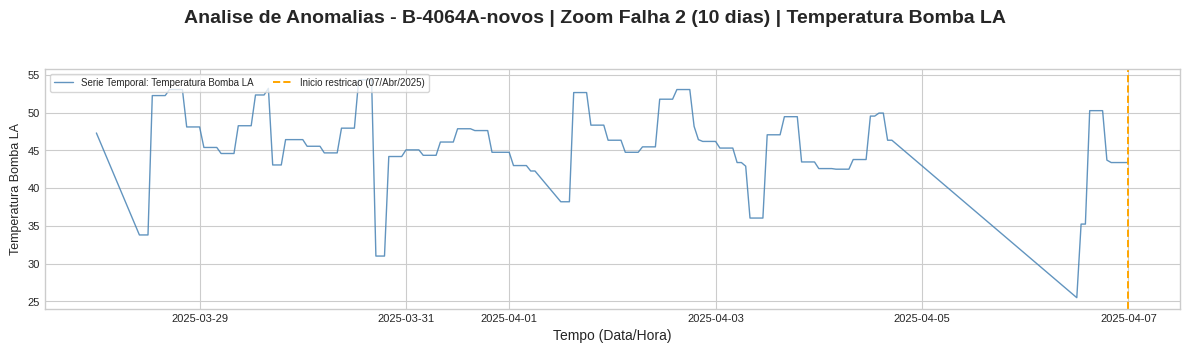

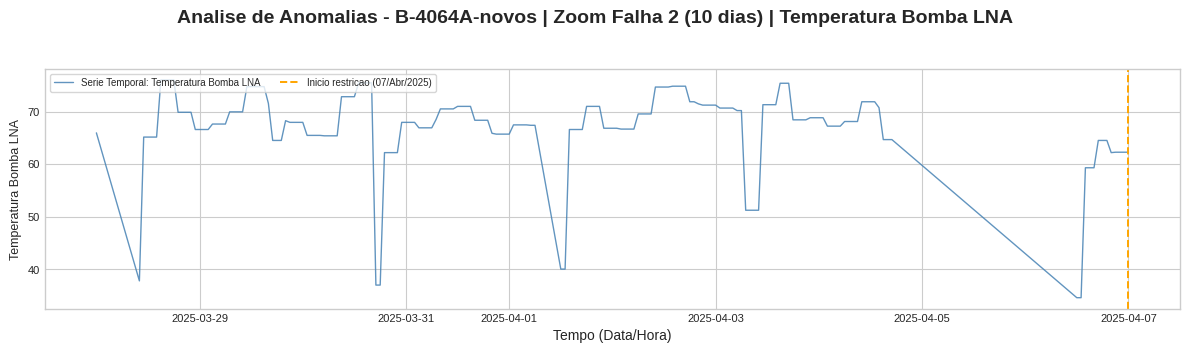

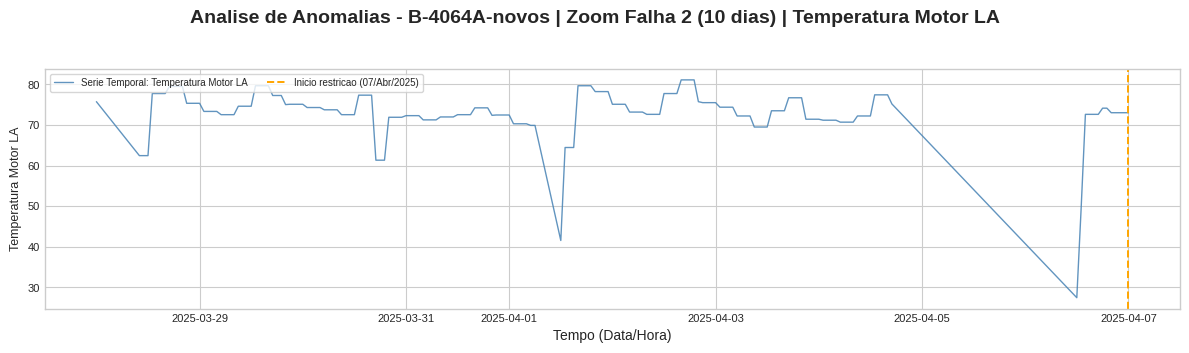

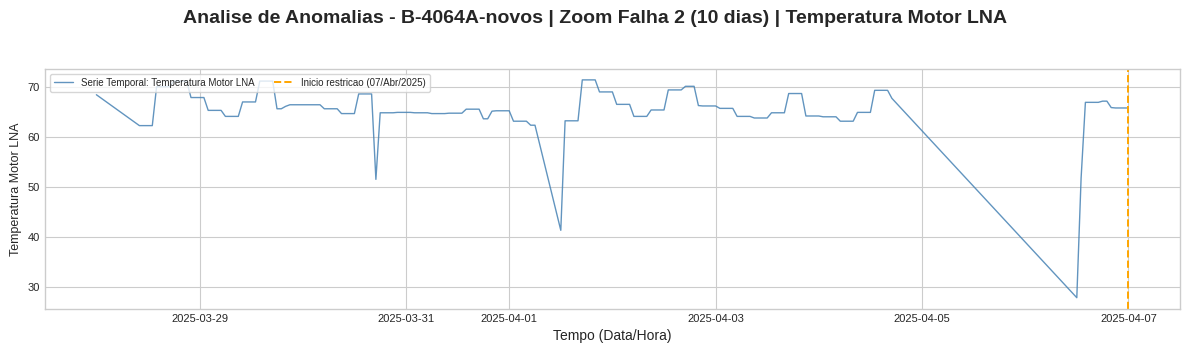

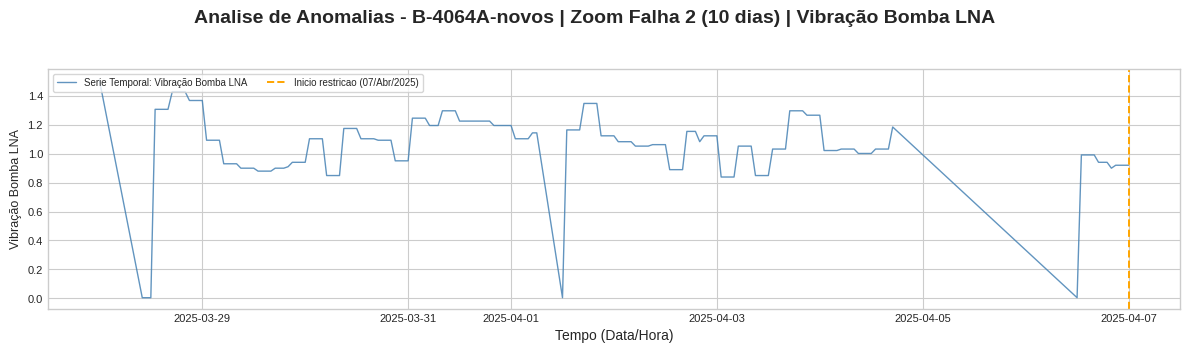

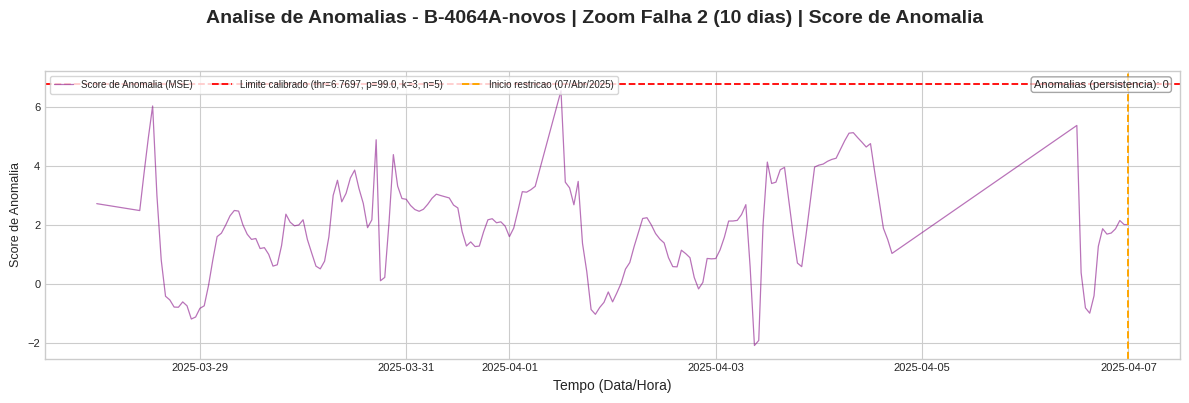


Resumo por janela:


,janela,inicio,fim,n_samples,n_anomalies,pct_anomalies,threshold,k,n
0,Falha 1 expandida,2024-01-01 01:00:00,2024-08-30 07:58:00,4894,5,0.10,6.769685,3,5
1,Zoom Falha 1 (10 dias),2024-08-20 07:58:00,2024-08-30 07:58:00,209,5,2.39,6.769685,3,5
2,Ano 2025 completo,2025-01-01 00:00:00,2025-12-31 00:00:00,6569,35,0.53,6.769685,3,5
3,Zoom Falha 2 (10 dias),2025-03-28 00:00:00,2025-04-07 00:00:00,185,0,0.00,6.769685,3,5


In [10]:
if TASK_ID == 'PASTE_TASK_ID_HERE':
    raise ValueError('Defina TASK_ID com o ID real da task no ClearML antes de executar.')

task, results, threshold, scores, score_artifact_name = load_task_outputs(
    TASK_ID,
    use_full_scores=USE_FULL_SCORES,
)

df_base, config = load_plot_base(EQUIPMENT_ID)
print_preprocessing_confirmation(config)
print()
print('Task:', task.id)
print('Artifact de score usado:', score_artifact_name)
print(f'Threshold (results): {threshold:.6f}')

preset = str(SENSITIVITY_PRESET).strip().lower()
eff_percentiles = list(CALIB_PERCENTILES)
eff_grid = list(CALIB_PERSISTENCE_GRID)
eff_target_alerts = float(TARGET_ALERTS_PER_DAY)

if preset == 'conservative':
    eff_percentiles = [99, 99.5, 99.7, 99.9]
    eff_grid = [(3, 5), (4, 6), (5, 8)]
    eff_target_alerts = 0.5
elif preset == 'sensitive':
    eff_percentiles = [95, 97, 98, 99]
    eff_grid = [(1, 1), (2, 3), (3, 5)]
    eff_target_alerts = 4.0
elif preset == 'balanced':
    pass
elif preset == 'custom':
    pass
else:
    raise ValueError("SENSITIVITY_PRESET invalido. Use: conservative, balanced, sensitive ou custom")

print('\nPreset de sensibilidade:', preset)
print('  Percentis:', eff_percentiles)
print('  Grid persistencia:', eff_grid)
print('  Meta alerts/day:', eff_target_alerts)
print('  Plot mode:', PLOT_MODE)
print('  Anomaly highlight style:', ANOMALY_HIGHLIGHT_STYLE)
print('  Save plots:', SAVE_PLOTS)

if AUTO_USE_CALIBRATED_SENSITIVITY:
    calib_input = scores.loc[pd.Timestamp(CALIB_START):pd.Timestamp(CALIB_END)].copy()
    # Sobrescreve parametros globais de calibracao com os efetivos do preset
    CALIB_PERCENTILES = eff_percentiles
    CALIB_PERSISTENCE_GRID = eff_grid
    TARGET_ALERTS_PER_DAY = eff_target_alerts

    sens = recommend_sensitivity(calib_input, CALIB_START, CALIB_END)
    selected_threshold = float(sens['threshold'])
    selected_k = int(sens['k'])
    selected_n = int(sens['n'])
    threshold_label = (
        f"Limite calibrado (thr={selected_threshold:.4f}, p={sens['percentile']:.1f}, k={selected_k}, n={selected_n})"
    )
    print('\nSensibilidade automatica ativa:')
    print(f"  Janela calibracao: {CALIB_START} .. {CALIB_END}")
    print(f"  Recomendado -> threshold={selected_threshold:.6f}, percentile={sens['percentile']:.1f}, k={selected_k}, n={selected_n}")
    print(f"  Alerts/day estimados (na janela de calibracao): {sens['alerts_per_day']:.3f}")
else:
    selected_threshold = float(threshold)
    selected_k = 1
    selected_n = 1
    threshold_label = f'Limite (threshold = {selected_threshold:.4f})'
    print('\nSensibilidade automatica desativada: usando threshold original da task.')

safe_task_id = TASK_ID.replace('/', '_').replace(':', '_')

WINDOW_F1_EXPANDED_START = scores.index.min()
WINDOW_F1_EXPANDED_END = EVENT_TS_F1

windows = [
    {
        'name': 'Falha 1 expandida',
        'start': WINDOW_F1_EXPANDED_START,
        'end': WINDOW_F1_EXPANDED_END,
        'event_date': EVENT_DATE_F1,
        'event_label': EVENT_LABEL_F1,
        'title': f'Analise de Anomalias - {EQUIPMENT_ID} | Falha 1 expandida',
        'out': PROJECT_ROOT / 'notebooks' / f'anomalias_b4064a_falha1_expandida_{safe_task_id}.png',
    },
    {
        'name': 'Zoom Falha 1 (10 dias)',
        'start': WINDOW_F1_ZOOM_START,
        'end': WINDOW_F1_ZOOM_END,
        'event_date': EVENT_DATE_F1,
        'event_label': EVENT_LABEL_F1,
        'title': f'Analise de Anomalias - {EQUIPMENT_ID} | Zoom Falha 1 (10 dias)',
        'out': PROJECT_ROOT / 'notebooks' / f'anomalias_b4064a_falha1_zoom10_{safe_task_id}.png',
    },
    {
        'name': 'Ano 2025 completo',
        'start': WINDOW_2025_START,
        'end': WINDOW_2025_END,
        'event_date': EVENT_DATE_F2,
        'event_label': EVENT_LABEL_F2,
        'title': f'Analise de Anomalias - {EQUIPMENT_ID} | Janela: 2025 completo',
        'out': PROJECT_ROOT / 'notebooks' / f'anomalias_b4064a_2025_full_{safe_task_id}.png',
    },
    {
        'name': 'Zoom Falha 2 (10 dias)',
        'start': WINDOW_F2_ZOOM_START,
        'end': WINDOW_F2_ZOOM_END,
        'event_date': EVENT_DATE_F2,
        'event_label': EVENT_LABEL_F2,
        'title': f'Analise de Anomalias - {EQUIPMENT_ID} | Zoom Falha 2 (10 dias)',
        'out': PROJECT_ROOT / 'notebooks' / f'anomalias_b4064a_2025_falha2_zoom10_{safe_task_id}.png',
    },
]

summary_rows = []

for w in windows:
    df_window, scores_window = slice_window(df_base, scores, w['start'], w['end'])
    threshold_flags = scores_window['reconstruction_error'] > selected_threshold
    anomaly_flags = persistence_filter(threshold_flags, k=selected_k, n=selected_n)
    n_anom = int(anomaly_flags.sum())

    saved_paths = plot_anomaly_panels(
        df_window=df_window,
        scores_window=scores_window,
        threshold_flags=threshold_flags,
        anomaly_flags=anomaly_flags,
        threshold=selected_threshold,
        threshold_label=threshold_label,
        n_anomalies=n_anom,
        event_date=pd.Timestamp(w['event_date']),
        event_label=w['event_label'],
        title=w['title'],
        output_path=w['out'],
        dpi=OUTPUT_DPI,
        plot_mode=PLOT_MODE,
        save_plots=SAVE_PLOTS,
        anomaly_highlight_style=ANOMALY_HIGHLIGHT_STYLE,
    )

    n_samples = len(scores_window)
    pct_anom = (100.0 * n_anom / n_samples) if n_samples else 0.0

    row = {
        'janela': w['name'],
        'inicio': pd.Timestamp(w['start']),
        'fim': pd.Timestamp(w['end']),
        'n_samples': n_samples,
        'n_anomalies': n_anom,
        'pct_anomalies': round(pct_anom, 2),
        'threshold': selected_threshold,
        'k': selected_k,
        'n': selected_n,
    }
    if SAVE_PLOTS:
        row['arquivos'] = ', '.join(str(x) for x in saved_paths)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print('\nResumo por janela:')
display(summary_df)
